In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch
torch.cuda.is_available()
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten, Reshape, Rescaling, Conv2D, MaxPooling2D
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
from keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train, train_size= 0.8, random_state=1)

In [25]:
def build_model(activation: str = 'relu') -> Sequential:
  model = Sequential([
    Input(shape=(28,28)),
    Reshape((28,28,1)), # reshape to add a dimension for convolution filters
    Rescaling(1./255), # place every value from 0 to 255 to between 0 and 1

    Conv2D(32,2,1,'same', activation=activation),
    Conv2D(32,2,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(64,2,1,'same', activation=activation),
    Conv2D(64,2,1,'same', activation=activation),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(64, activation=activation),
    Dense(64, activation=activation),
    Dense(64, activation=activation),
    Dense(64, activation=activation),
    Dense(10, activation='softmax'), #10 categories of dogs
    # Dense(1,activation='linear'), # 1 stock price 
    # Dense(1, activation='sigmoid') # 1 "boolean"
  
  ])

  model.compile(optimizer=Adam(),
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model

model = build_model()
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_15 (Reshape)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_15 (Rescaling)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 28, 28, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 28, 28, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 14, 14, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,890 (948.79 KB)

 Trainable params: 242,890 (948.79 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(x_train, y_train, 512, 20, validation_data=(x_val, y_val))

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6578 - loss: 0.8979 - val_accuracy: 0.8217 - val_loss: 0.4897
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8400 - loss: 0.4388 - val_accuracy: 0.8570 - val_loss: 0.3910
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8680 - loss: 0.3682 - val_accuracy: 0.8652 - val_loss: 0.3681
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8816 - loss: 0.3283 - val_accuracy: 0.8871 - val_loss: 0.3148
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8933 - loss: 0.2977 - val_accuracy: 0.8920 - val_loss: 0.2970
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8997 - loss: 0.2770 - val_accuracy: 0.8918 - val_loss: 0.2992
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9055 - loss: 0.2577 - val_accuracy: 0.8996 - val_loss: 0.2698
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9112 - loss: 0.2436 - val_accuracy: 0.9020 - v

/tmp/ipykernel_14452/2078258904.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(model.layers[-1].weights[0]))


<Axes: ylabel='Density'>

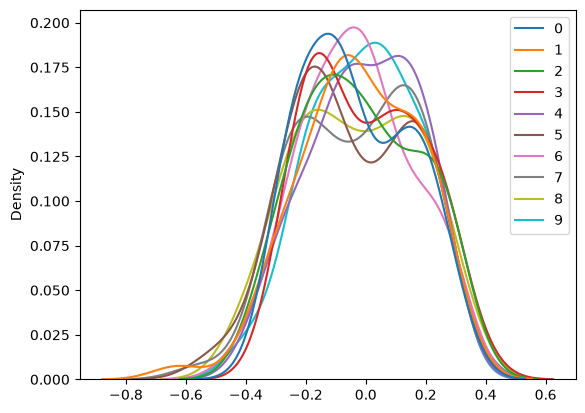

In [53]:
sns.kdeplot(np.array(model.layers[-1].weights[0]))

In [28]:
for idx, layer in enumerate(model.layers):
  print(f'{idx}: {layer.name}')
  

0: reshape_15
1: rescaling_15
2: conv2d_108
3: conv2d_109
4: max_pooling2d_54
5: conv2d_110
6: conv2d_111
7: max_pooling2d_55
8: flatten_14
9: dense_32
10: dense_33
11: dense_34
12: dense_35
13: dense_36


In [51]:
f_map_extractor = Model(inputs=model.inputs, outputs=model.layers[7].output)
f_map = f_map_extractor.predict(x_test)
print('f_map: ', f_map.shape)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
f_map:  (10000, 7, 7, 64)


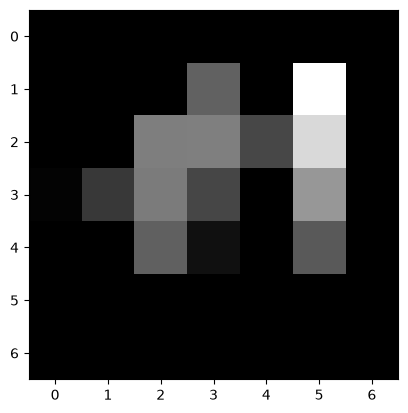

In [52]:
plt.imshow(f_map[0][:,:,5], cmap="gray")

In [61]:
f_map[0,0,0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.70389193, 0.        , 0.        , 0.        ,
       0.18888143, 0.21277015, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.5266453 ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.51233363, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.89871585, 0.7130443 ,
       0.07334575, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.11413893], dtype=float32)

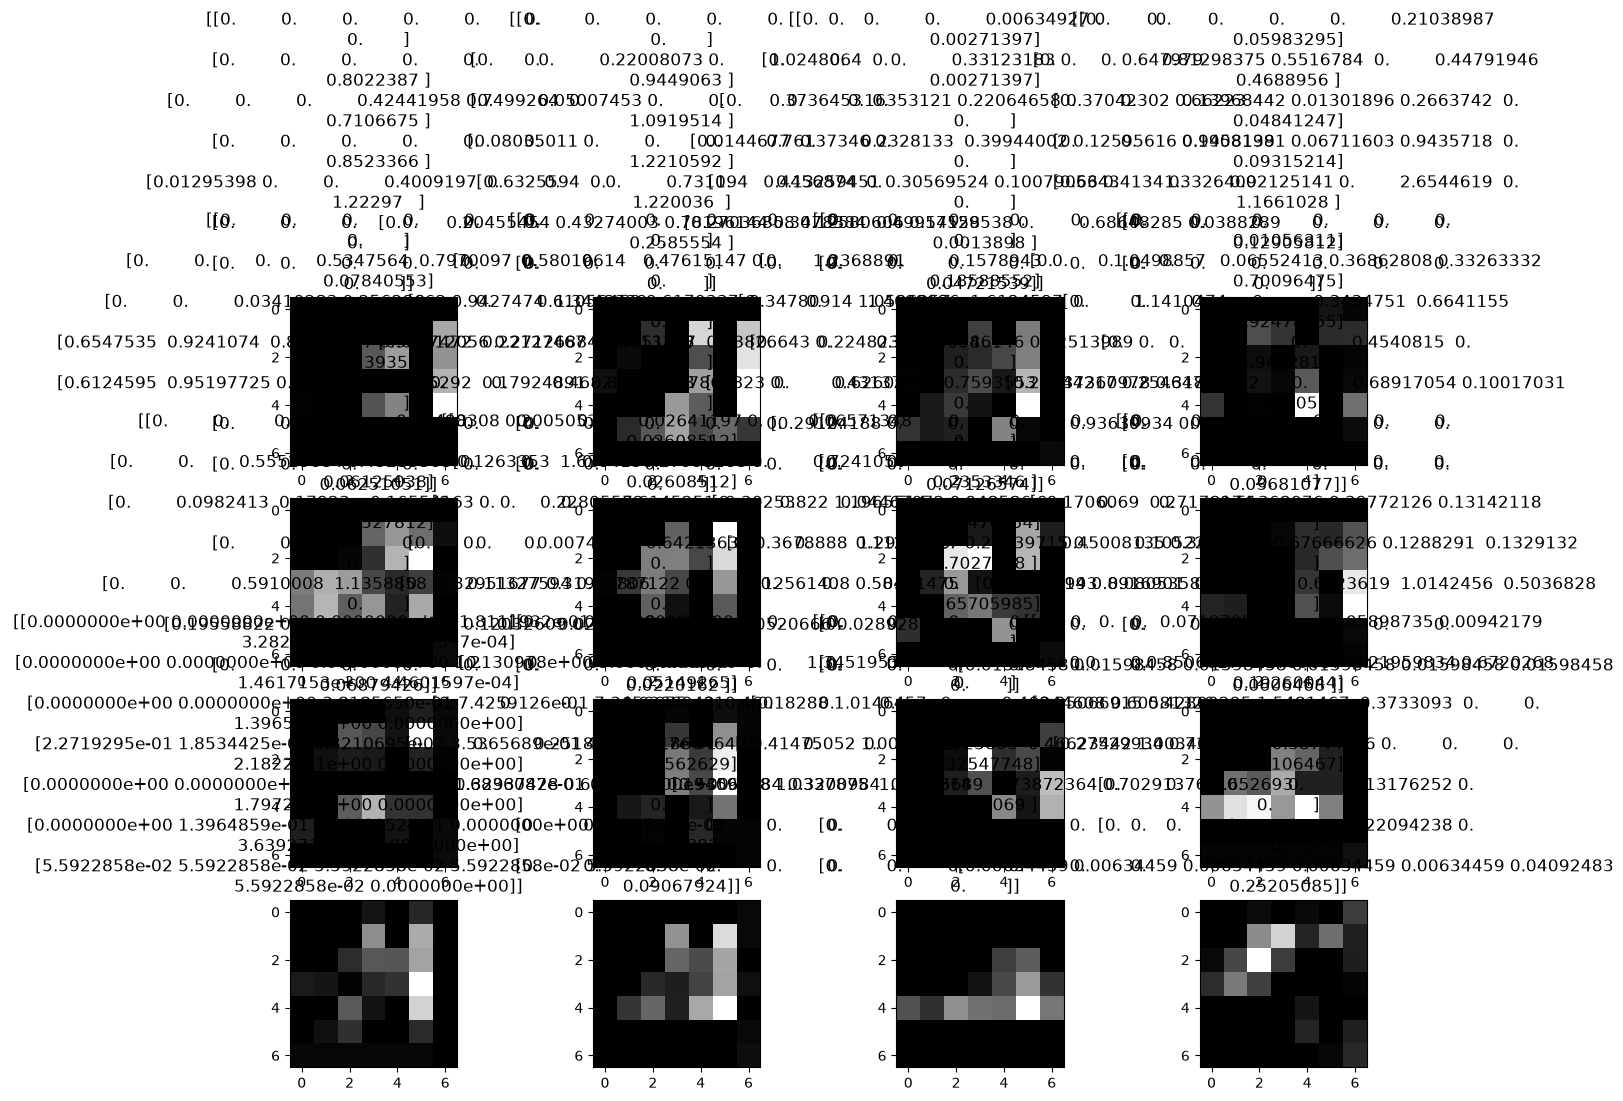

In [ ]:
labels={0:'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',5:'Sandal',6:'Shirt',7:'Sneaker',8:'Bag',9:'Ankle_boot'}
def draw_images(f_map, layer=0):
  plt.figure(figsize=(15,10))
  for i in enumerate(y_val16):
    plt.subplot(4,4, i+1)
    item = f_map[layer][:,:,i]
    plt.title(labels[x_val[i]])
    plt.imshow(item, cmap="gray")

draw_images(f_map)